### Plan
1. Getting familiar with scipy STFT and ISTFT
2. Streaming STFT and ISTFT implementation
3. Toy noise reduction with a low-pass filter

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf

# Streaming STFT and ISTFT

**This is the input we will work with**

In [2]:
PATH_IN_FOR_STFT = "data/mixture.wav"

### STFT in scipy

We will use the older version:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.stft.html

Currently it is deprecated, it's ok for our needs.

In [3]:
import scipy.signal as sig

SR = 16_000

x, sr = sf.read(PATH_IN_FOR_STFT)
assert sr == SR

# These arguments are often used in speech processing.
# We picked win_size % hop_size != 0 to make the things more general
win_size = 400
hop_size = 160
n_fft = 512
window = np.hanning(win_size)

shape: (257, 397)


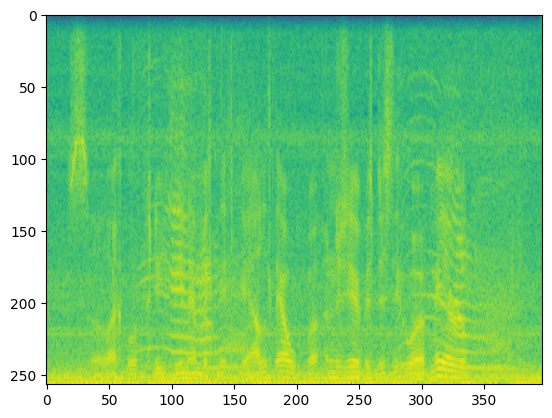

In [4]:
*_, spec = sig.stft(
    x, nfft=n_fft, nperseg=win_size, noverlap=win_size - hop_size,
    window=window
)


print("shape:", spec.shape)

_, ax = plt.subplots()
ax.imshow(np.flip(np.log(np.abs(spec))))
ax.set_aspect('auto')
plt.show()

**ISTFT: the inverse of STFT**

In [5]:
_, x_restored = sig.istft(
    spec, nfft=n_fft, nperseg=win_size, noverlap=win_size - hop_size,
    window=window
)
print("shapes: source signal and after reconstruction")
print(x.shape, x_restored.shape)
print()
x_restored = x_restored[:len(x)]

print("max-abs error")
diff = np.abs(x - x_restored).max() 
print(diff)
assert diff < 1e-12

shapes: source signal and after reconstruction
(63295,) (63360,)

max-abs error
2.220446049250313e-16


### Streaming data

The following function reads an audio file chunk-by-chunk.

In practice audio chunks come from microphones. After VQE sound goes to the voice call.

In [6]:
gen = sf.blocks(PATH_IN_FOR_STFT, blocksize=hop_size)

print("chunk shapes:")
for chunk_idx, chunk in enumerate(gen):
    print(chunk.shape)
    if chunk_idx >= 3:
        break

# the audio file is open for reading -> we should close it
gen.close()

chunk shapes:
(160,)
(160,)
(160,)
(160,)


**For testing purposes** we define a chunk streamer from numpy.ndarrays:

In [7]:
from collections.abc import Iterator


class NpArrayChunker:
    def __init__(self, x, chunk_size: int) -> None:
        self.x = x
        self.chunk_size = chunk_size
        self.start = 0

    def _get_next_chunk(self) -> np.ndarray:
        end = min(self.start + self.chunk_size, len(self.x))
        result = self.x[self.start : end]
        self.start = end
        return result

    def __iter__(self) -> Iterator[np.ndarray]:
        while self.start != len(self.x):
            yield self._get_next_chunk()

**Let's see how it works:**

In [8]:
x = np.arange(10)

chunker = NpArrayChunker(x, 2)

print("array:")
print(x)
print("chunks:")
for chunk in chunker:
    print(chunk)

array:
[0 1 2 3 4 5 6 7 8 9]
chunks:
[0 1]
[2 3]
[4 5]
[6 7]
[8 9]


**We can define another chunk size:**

In [9]:
chunker = NpArrayChunker(x, 3)

print("array:")
print(x)
print("chunks")
for chunk in chunker:
    print(chunk)

array:
[0 1 2 3 4 5 6 7 8 9]
chunks
[0 1 2]
[3 4 5]
[6 7 8]
[9]


**The last chunk is not full, which matches the situation when the input stream does not come in full chunks**

## Coding time

### Streaming sliding window

In [10]:
class StreamingSlidingWindow:
    """
    Implements streaming sliding window.

    It means that inputs can come in small chunks. In practice chunks are small, but this class will handle
    arbitrarily sized chunks.

    How it should work (the __call__ method):
    It should accumulate chunks of full input and as soon as a full window
    (or several windows with hops as input chunks can be large, too)
    is accumulated, it should be yielded and the necessary part of accumulated input should be dropped,
    resulting in O(win_size + input_chunk_size) complexity in computation an memory.

    """

    def __init__(
        self, win_size: int, hop_size: int, initial_fill: np.ndarray | None = None
    ) -> None:
        assert win_size >= hop_size, (win_size, hop_size)
        self.win_size = win_size
        self.hop_size = hop_size

        # this is where the pieces of input are accumulated
        self.next_window_prefix: np.ndarray | None = initial_fill

    def __call__(self, chunk: np.ndarray) -> Iterator[np.ndarray]:
        """
        Updates streaming sliding window from a new input chunk
        """
        if self.next_window_prefix is None:
            chunk_full = chunk
        else:
            chunk_full = np.concatenate([self.next_window_prefix, chunk], axis=0)

        start_idx = 0
        while start_idx + self.win_size <= len(chunk_full):
            end_idx = start_idx + self.win_size
            window = chunk_full[start_idx:end_idx]
            yield window
            start_idx = start_idx + self.hop_size

        self.next_window_prefix = chunk_full[start_idx:]

    def zero_pad_cache(self) -> None:
        """
        Pads self.next_window_prefix with zeros to match the full win_size if it is not empty.

        We need this function to process the final part of input which does not fill a full window.
        """
        if self.next_window_prefix is None:
            return
        rest = self.win_size - len(self.next_window_prefix)
        if rest == 0:
            return
        padding = np.zeros(
            [*self.next_window_prefix.shape[:-1], rest],
            dtype=self.next_window_prefix.dtype,
        )
        self.next_window_prefix = np.concatenate([self.next_window_prefix, padding])


**Now let's test StreamingSlidingWindow and observe its behavior**

In [11]:
def observe_sliding_window(sig_len: int, win_size: int, hop_size: int, chunk_size: int):
    x = np.arange(sig_len) + 1

    print("signal:")
    print(x)
    print()

    window_transform = StreamingSlidingWindow(win_size, hop_size)
    windows = []

    for chunk_idx, chunk in enumerate(NpArrayChunker(x, chunk_size)):
        print("chunk_idx:", chunk_idx)
        print("chunk:", chunk)
        windows_from_chunk = list(window_transform(chunk))
        print("windows from the chunk:", windows_from_chunk)
        windows += windows_from_chunk
        print()

    sliding_window_result = np.stack(windows).T
    print()
    print("result:")
    print(sliding_window_result)
    
    return sliding_window_result

**A simple example:**

In [12]:
result = observe_sliding_window(sig_len=10, win_size=4, hop_size=2, chunk_size=2)

answer = np.array([
    [1, 2, 3, 4],
    [3, 4, 5, 6],
    [5, 6, 7, 8],
    [7, 8, 9, 10],
]).T

assert np.all(result == answer)

signal:
[ 1  2  3  4  5  6  7  8  9 10]

chunk_idx: 0
chunk: [1 2]
windows from the chunk: []

chunk_idx: 1
chunk: [3 4]
windows from the chunk: [array([1, 2, 3, 4])]

chunk_idx: 2
chunk: [5 6]
windows from the chunk: [array([3, 4, 5, 6])]

chunk_idx: 3
chunk: [7 8]
windows from the chunk: [array([5, 6, 7, 8])]

chunk_idx: 4
chunk: [ 9 10]
windows from the chunk: [array([ 7,  8,  9, 10])]


result:
[[ 1  3  5  7]
 [ 2  4  6  8]
 [ 3  5  7  9]
 [ 4  6  8 10]]


**Question:** the output for the first chunk is empty. Why?

**Another signal duration:**

In [13]:
result = observe_sliding_window(sig_len=11, win_size=4, hop_size=2, chunk_size=2)

answer = np.array([
    [1, 2, 3, 4],
    [3, 4, 5, 6],
    [5, 6, 7, 8],
    [7, 8, 9, 10],
]).T

assert np.all(result == answer)

signal:
[ 1  2  3  4  5  6  7  8  9 10 11]

chunk_idx: 0
chunk: [1 2]
windows from the chunk: []

chunk_idx: 1
chunk: [3 4]
windows from the chunk: [array([1, 2, 3, 4])]

chunk_idx: 2
chunk: [5 6]
windows from the chunk: [array([3, 4, 5, 6])]

chunk_idx: 3
chunk: [7 8]
windows from the chunk: [array([5, 6, 7, 8])]

chunk_idx: 4
chunk: [ 9 10]
windows from the chunk: [array([ 7,  8,  9, 10])]

chunk_idx: 5
chunk: [11]
windows from the chunk: []


result:
[[ 1  3  5  7]
 [ 2  4  6  8]
 [ 3  5  7  9]
 [ 4  6  8 10]]


**Question:** the output for the last chunk is empty, and the signal was not transformed completely. Why?

**We can use initial fill and zero_pad_cache for zero padding:**

In [14]:
def observe_sliding_window_v2(sig_len: int, win_size: int, hop_size: int, chunk_size: int, padding: bool = False):
    x = np.arange(sig_len) + 1

    print("signal:")
    print(x)
    print()

    window_transform = StreamingSlidingWindow(
        win_size, hop_size,
        # note initial_fill!
        initial_fill=np.zeros(win_size - hop_size, dtype=x.dtype) if padding else None
    )
    windows = []

    for chunk_idx, chunk in enumerate(NpArrayChunker(x, chunk_size)):
        print("chunk:", chunk)
        windows_from_chunk = list(window_transform(chunk))
        print("windows from the chunk:", windows_from_chunk)
        windows += windows_from_chunk
        print()

    # note this post-processing!
    window_transform.zero_pad_cache()
    for chunk in [np.array([0])[:0]]:
        print("chunk:", chunk)
        windows_from_chunk = list(window_transform(chunk))
        print("windows from the chunk:", windows_from_chunk)
        windows += windows_from_chunk

    sliding_window_result = np.stack(windows).T
    print()
    print("result:")
    print(sliding_window_result)
    
    return sliding_window_result

In [15]:
result = observe_sliding_window_v2(sig_len=11, win_size=4, hop_size=2, chunk_size=2, padding=True)

answer = np.array([
    [0, 0, 1, 2],
    [1, 2, 3, 4],
    [3, 4, 5, 6],
    [5, 6, 7, 8],
    [7, 8, 9, 10],
    [9, 10, 11, 0],
]).T

assert np.all(result == answer)

signal:
[ 1  2  3  4  5  6  7  8  9 10 11]

chunk: [1 2]
windows from the chunk: [array([0, 0, 1, 2])]

chunk: [3 4]
windows from the chunk: [array([1, 2, 3, 4])]

chunk: [5 6]
windows from the chunk: [array([3, 4, 5, 6])]

chunk: [7 8]
windows from the chunk: [array([5, 6, 7, 8])]

chunk: [ 9 10]
windows from the chunk: [array([ 7,  8,  9, 10])]

chunk: [11]
windows from the chunk: []

chunk: []
windows from the chunk: [array([ 9, 10, 11,  0])]

result:
[[ 0  1  3  5  7  9]
 [ 0  2  4  6  8 10]
 [ 1  3  5  7  9 11]
 [ 2  4  6  8 10  0]]


**Right padding looks a little clumsy:** we could optimize it away, but that's not the point.

**Finally let's oberve our sliding window with hop_size $\neq$ chunk_size**

In [16]:
result = observe_sliding_window_v2(sig_len=11, win_size=4, hop_size=2, chunk_size=3, padding=True)

answer = np.array([
    [0, 0, 1, 2],
    [1, 2, 3, 4],
    [3, 4, 5, 6],
    [5, 6, 7, 8],
    [7, 8, 9, 10],
    [9, 10, 11, 0],
]).T

assert np.all(result == answer)

signal:
[ 1  2  3  4  5  6  7  8  9 10 11]

chunk: [1 2 3]
windows from the chunk: [array([0, 0, 1, 2])]

chunk: [4 5 6]
windows from the chunk: [array([1, 2, 3, 4]), array([3, 4, 5, 6])]

chunk: [7 8 9]
windows from the chunk: [array([5, 6, 7, 8])]

chunk: [10 11]
windows from the chunk: [array([ 7,  8,  9, 10])]

chunk: []
windows from the chunk: [array([ 9, 10, 11,  0])]

result:
[[ 0  1  3  5  7  9]
 [ 0  2  4  6  8 10]
 [ 1  3  5  7  9 11]
 [ 2  4  6  8 10  0]]


**The result should not change.** Because only the order of computations is influenced, not the mathematical operation.

Note 2 output windows for one of the input chunks.

### Streaming overlap-add

In [17]:
class StreamingOverlapAdd:
    """
    Implements streaming overlap-add.
    """

    def __init__(self, hop_size: int, win_size: int) -> None:
        self.hop_size = hop_size
        self.win_size = win_size
        self.out_window: np.ndarray = np.zeros(win_size)
        self.out_weight: np.ndarray = np.zeros(win_size)

    def __call__(self, window: np.ndarray, weights: np.ndarray | None = None):
        """
        Takes a window with corresponding weights.
        Adds the window with the weights to the accumulated values.

        The accumulated values which will no longer be modified by upcoming windows
        are returned, divided by their total weights.

        """
        assert len(window) == self.win_size
        if weights is None:
            weights = np.ones(len(window))
        window_full = np.copy(window.astype(np.float64))
        weight_full = np.copy(weights.astype(np.float64))
#         if self.out_window is not None:
#             assert self.out_weight is not None
#             # calculate actual values in window_full and weight_full
        window_full = self.out_window + window
        weight_full = self.out_weight + weights
    
        window_out = window_full[:self.hop_size]
        weight_out = weight_full[:self.hop_size]

        result = window_out / weight_out

        self.out_window = np.concatenate([window_full[self.hop_size:], np.zeros(self.hop_size)])
        self.out_weight = np.concatenate([weight_full[self.hop_size:], np.zeros(self.hop_size)])

        return result

**Let's test and observe the behavior of Overlap-Add**

In [18]:
def observe_overlap_add(
    sig_len: int, win_size: int, hop_size: int,
    chunk_size: int, padding: bool = False,
    window_fn=np.ones,
):
    x = np.arange(sig_len) + 1

    print("signal:")
    print(x)
    print()
    
    window_mult = window_fn(win_size)

    window_transform = StreamingSlidingWindow(
        win_size, hop_size,
        initial_fill=np.zeros(win_size - hop_size, dtype=x.dtype) if padding else None
    )
    overlap_add = StreamingOverlapAdd(hop_size=hop_size, win_size=win_size)
    
    windows = []
    signal_restored = []

    for chunk_idx, chunk in enumerate(NpArrayChunker(x, chunk_size)):
        print("chunk:", chunk)
        windows_from_chunk = list(window_transform(chunk))
        print("windows from the chunk:", windows_from_chunk)
        windows += windows_from_chunk
        
        # this is done inside STFT
        windows_weighted = [x * window_mult for x in windows_from_chunk]

        # this is done inside ISTFT
        wins_weighted_twice = [x * window_mult for x in windows_weighted]

        chunks_restored = [overlap_add(win, window_mult ** 2) for win in wins_weighted_twice]
        signal_restored += chunks_restored
        print("chunks restored:", chunks_restored)
        print()
        
    sliding_window_result = np.stack(windows).T
    signal_restored = np.concatenate(signal_restored)
    
    return signal_restored

In [19]:
answer = np.arange(1, 9)
result = observe_overlap_add(10, 4, 2, 2, False)

assert np.allclose(answer, result)

signal:
[ 1  2  3  4  5  6  7  8  9 10]

chunk: [1 2]
windows from the chunk: []
chunks restored: []

chunk: [3 4]
windows from the chunk: [array([1, 2, 3, 4])]
chunks restored: [array([1., 2.])]

chunk: [5 6]
windows from the chunk: [array([3, 4, 5, 6])]
chunks restored: [array([3., 4.])]

chunk: [7 8]
windows from the chunk: [array([5, 6, 7, 8])]
chunks restored: [array([5., 6.])]

chunk: [ 9 10]
windows from the chunk: [array([ 7,  8,  9, 10])]
chunks restored: [array([7., 8.])]



In [20]:
signal_restored = observe_overlap_add(10, 4, 2, 2, False, window_fn=np.hanning)
print("result:")
print(signal_restored)

signal:
[ 1  2  3  4  5  6  7  8  9 10]

chunk: [1 2]
windows from the chunk: []
chunks restored: []

chunk: [3 4]
windows from the chunk: [array([1, 2, 3, 4])]
chunks restored: [array([nan,  2.])]

chunk: [5 6]
windows from the chunk: [array([3, 4, 5, 6])]
chunks restored: [array([3., 4.])]

chunk: [7 8]
windows from the chunk: [array([5, 6, 7, 8])]
chunks restored: [array([5., 6.])]

chunk: [ 9 10]
windows from the chunk: [array([ 7,  8,  9, 10])]
chunks restored: [array([7., 8.])]

result:
[nan  2.  3.  4.  5.  6.  7.  8.]


/tmp/ipykernel_13523/4181565790.py:35: RuntimeWarning: invalid value encountered in divide
  result = window_out / weight_out


**See the nan?** The signal was restored correctly, however the first value turned into nan.

This happened because there was no window overlap for the first index, and the window_mult value is 0 there.

It's an edge effect: the first (win_size - hop_size) samples can experience problems.

How to handle it? Use padding in window transform. If we apply left padding for win_size - hop_size samples, the edge effect will only influence the padding values.

Anyway, it is not a big deal for long streams.

In [21]:
answer = np.arange(1, 9)

win_size = 4
hop_size = 2
signal_restored = observe_overlap_add(10, win_size, hop_size, 2, padding=True, window_fn=np.hanning)
signal_restored = signal_restored[win_size - hop_size:]
print("result:")
print(signal_restored)

assert np.allclose(signal_restored, answer)

signal:
[ 1  2  3  4  5  6  7  8  9 10]

chunk: [1 2]
windows from the chunk: [array([0, 0, 1, 2])]
chunks restored: [array([nan,  0.])]

chunk: [3 4]
windows from the chunk: [array([1, 2, 3, 4])]
chunks restored: [array([1., 2.])]

chunk: [5 6]
windows from the chunk: [array([3, 4, 5, 6])]
chunks restored: [array([3., 4.])]

chunk: [7 8]
windows from the chunk: [array([5, 6, 7, 8])]
chunks restored: [array([5., 6.])]

chunk: [ 9 10]
windows from the chunk: [array([ 7,  8,  9, 10])]
chunks restored: [array([7., 8.])]

result:
[1. 2. 3. 4. 5. 6. 7. 8.]


/tmp/ipykernel_13523/4181565790.py:35: RuntimeWarning: invalid value encountered in divide
  result = window_out / weight_out


### Streaming STFT:

$$STFT = \text{DFT} \cdot \text{zero_pad} \cdot \text{window_multiplication} \cdot \text{sliding_window}$$

$$ISTFT = \text{overlap_add} \cdot \text{window_multiplication} \cdot \text{crop} \cdot \text{IDFT}$$

In [22]:
class StreamingStft:
    def __init__(
        self,
        n_fft: int,
        window: np.ndarray,
        hop_size: int,
        padding_mode: str = "torch",
        left_padding: bool = False,
    ) -> None:
        self.window = window
        win_size = len(window)
        self.window_transform = StreamingSlidingWindow(
            win_size=win_size,
            hop_size=hop_size,
            initial_fill=np.zeros(win_size - hop_size) if left_padding else None,
        )
        self.n_fft = n_fft
        assert n_fft >= win_size, (n_fft, win_size)
        assert n_fft % 2 == win_size % 2 == 0, (n_fft, win_size)
        self.side_padding = (n_fft - win_size) // 2
        self.padding_mode = padding_mode
        self.left_padding = left_padding

    def __call__(self, chunk: np.ndarray) -> Iterator[np.ndarray]:
        for sliding_window in self.window_transform(chunk):
            smoothened = sliding_window * self.window
            padding = np.zeros(self.side_padding)
            if self.padding_mode == "torch":
                padded = np.concatenate([padding, smoothened, padding])
            elif self.padding_mode == "scipy":
                padded = np.concatenate([smoothened, padding, padding])
            else:
                assert False, self.padding_mode
            stft_chunk = np.fft.rfft(padded)  # fft for real-valued inputs
            yield stft_chunk

**Let's compare against scipy:**

In [23]:
win_size = 400
hop_size = 160
n_fft = 512

window = np.hanning(win_size)

In [24]:
x, _ = sf.read(PATH_IN_FOR_STFT)
*_, spec_scipy = sig.stft(
    x, nfft=n_fft, nperseg=win_size, noverlap=win_size - hop_size, padded=False, boundary=None,
    window=window
)
spec_scipy.shape

(257, 394)

(257, 394)


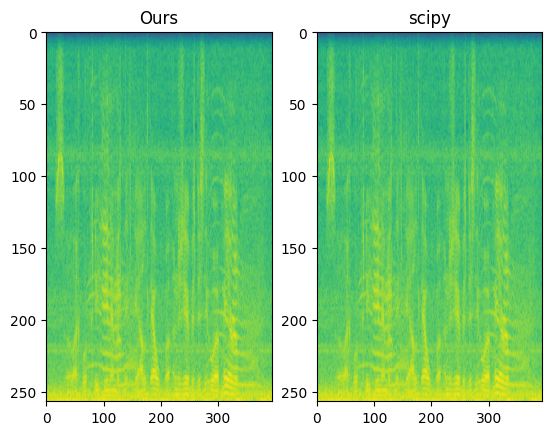

In [25]:
stft = StreamingStft(n_fft, window, hop_size, padding_mode="scipy")

spec = []
    
for chunk in sf.blocks(PATH_IN_FOR_STFT, blocksize=hop_size, overlap=0):
    stft_chunks = list(stft(chunk))
    spec += stft_chunks

spec = np.stack(spec).T
print(spec.shape)

_, axes = plt.subplots(ncols=2)

ax = axes[0]
ax.set_title("Ours")
ax.imshow(np.flip(np.log(np.abs(spec))))
ax.set_aspect('auto')

ax = axes[1]
ax.set_title("scipy")
ax.imshow(np.flip(np.log(np.abs(spec_scipy))))
ax.set_aspect('auto')
plt.show()

**Scipy applies scaling in stft.** Let's evaluate and compensate for it:

In [26]:
spec.shape, spec_scipy.shape

((257, 394), (257, 394))

In [27]:
scaling_mult = win_size // 2 - 0.5
np.abs(spec / spec_scipy).max(), np.abs(spec / spec_scipy).min(), scaling_mult

(np.float64(199.50000000000009), np.float64(199.49999999999994), 199.5)

**Difference:**

In [28]:
diff = np.abs(spec - spec_scipy * scaling_mult).max()
print(diff)
assert diff < 1e-10, diff
print("Great job!")

3.972054645195637e-15
Great job!


### Streaming ISTFT

$$STFT = \text{DFT} \cdot \text{zero_pad} \cdot \text{window_multiplication} \cdot \text{sliding_window}$$

$$ISTFT = \text{overlap_add} \cdot \text{window_multiplication} \cdot \text{crop} \cdot \text{IDFT}$$

In [29]:
class StreamingIStft:
    def __init__(
        self,
        n_fft: int,
        window: np.ndarray,
        hop_size: int,
        padding_mode: str = "torch",
    ) -> None:
        self.window = window
        win_size = len(window)
        self.overlap_add = StreamingOverlapAdd(hop_size=hop_size, win_size=len(window))
        self.n_fft = n_fft
        assert n_fft >= win_size, (n_fft, win_size)
        assert n_fft % 2 == win_size % 2 == 0, (n_fft, win_size)
        self.side_padding = (n_fft - win_size) // 2
        self.padding_mode = padding_mode

    def __call__(
        self, spectral_window: np.ndarray, input_window_weight: np.ndarray | None = None
    ) -> np.ndarray:
        if input_window_weight is None:
            input_window_weight = self.window
        window_padded = np.fft.irfft(spectral_window)  # inverse rfft
        if self.padding_mode == "torch":
            crop = window_padded[self.side_padding: -self.side_padding]
        elif self.padding_mode == "scipy":
            if self.side_padding > 0:
                crop = window_padded[:-2 * self.side_padding]
            else:
                crop = window_padded
        window_smoothened = crop * self.window
        weight = self.window * input_window_weight
        chunk_out = self.overlap_add(window_smoothened, weight)
        return chunk_out

**Let's check that ISTFT is the inverse of STFT**

/tmp/ipykernel_13523/4181565790.py:35: RuntimeWarning: invalid value encountered in divide
  result = window_out / weight_out


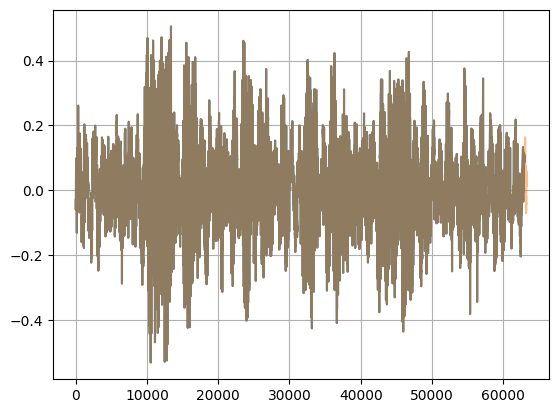

diff: 2.220446049250313e-16


In [30]:
padding_mode = "scipy"
stft = StreamingStft(n_fft, window, hop_size, padding_mode=padding_mode, left_padding=True)
istft = StreamingIStft(n_fft, window, hop_size, padding_mode=padding_mode)

waveform_restored = []
for chunk in sf.blocks(PATH_IN_FOR_STFT, blocksize=hop_size, overlap=0):
    stft_chunks = list(stft(chunk))
    for stft_chunk in stft_chunks:
        waveform_restored_chunk = istft(stft_chunk)
        waveform_restored.append(waveform_restored_chunk)

waveform_restored = np.concatenate(waveform_restored)[len(window) - hop_size:]
waveform, _ = sf.read(PATH_IN_FOR_STFT)

_, ax = plt.subplots()
ax.plot(waveform_restored)
ax.plot(waveform, alpha=0.5)
ax.grid()
plt.show()

common_prefix = min(len(waveform_restored), len(waveform))

diff = np.abs(waveform_restored[:common_prefix] - waveform[:common_prefix]).max()

print("diff:", diff)
assert diff < 1e-12

# Simple VQE

We will implement Spectral Subtraction and Wiener Filter

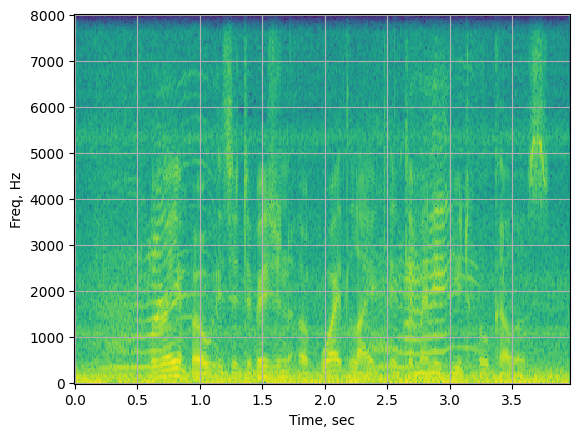

In [31]:
PATH_IN_FOR_CLASSIC_NR = "data/mixture.wav"
N_FFT = 512
win_size = 320
hop_size = 160

# bigger window produces bigger latency
# N_FFT = 2048
# win_size = 2048
# hop_size = 512

x, sr = sf.read(PATH_IN_FOR_CLASSIC_NR)
assert sr == SR

f, t, spec = sig.stft(x, nfft=N_FFT, nperseg=win_size, noverlap=win_size - hop_size, fs=SR)

_, ax = plt.subplots()
ax.pcolormesh(t, f, np.log(np.abs(spec) + 1e-8))
ax.set_xlabel("Time, sec")
ax.set_ylabel("Freq, Hz")
ax.set_aspect("auto")
ax.grid()
plt.show()

**Let's apply utterance-level Spectral Subtraction and Wiener Filter to the input.**

In [32]:
def apply_classic_nr_utterance_on_spectrogram(input_spec):
    mag = np.abs(input_spec)
    phase = spec / np.clip(mag, 1e-8, None)
    noise_est = np.mean(mag, axis=1, keepdims=True)

    # spectral subtraction
    mag_enh_spectral_subtracion = mag - noise_est
    mag_enh_spectral_subtracion = np.clip(mag_enh_spectral_subtracion, 0, None)

    # Wiener filter
    mixture_power = mag ** 2
    noise_est_power = noise_est ** 2
    snr_power = mixture_power / noise_est_power - 1
    snr_power = np.clip(snr_power, 0, None)
    gain = snr_power / (snr_power + 1)
    mag_enh_wiener = mag * gain
    
    outputs = {
        "spectral_subtraction": mag_enh_spectral_subtracion * phase,
        "wiener": mag_enh_wiener * phase
    }
    return outputs

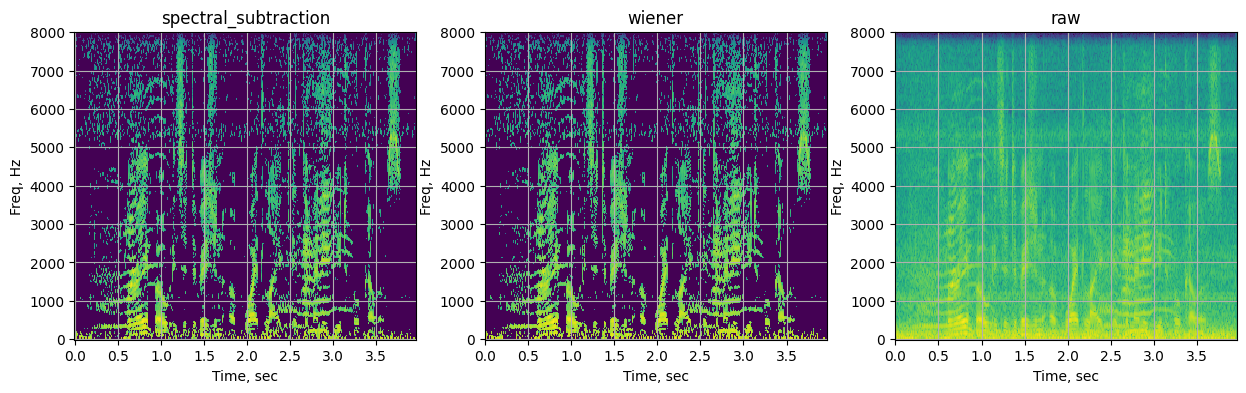

In [33]:
utterance_classic_nr_outputs = apply_classic_nr_utterance_on_spectrogram(spec)
utterance_classic_nr_outputs["raw"] = spec

for algo_name, algo_output_complex_spec in utterance_classic_nr_outputs.items():
    _, wave = sig.istft(algo_output_complex_spec, fs=SR, nperseg=win_size, noverlap=win_size-hop_size)
    sf.write(f"data/utterance_{algo_name}.wav", wave, sr)

_, axes = plt.subplots(ncols=len(utterance_classic_nr_outputs), figsize=(15, 4))
for idx, (algo_name, algo_output) in enumerate(utterance_classic_nr_outputs.items()):
    ax = axes[idx]
    ax.set_title(algo_name)
    ax.pcolormesh(t, f, np.log(np.abs(algo_output) + 1e-8))
    ax.set_xlabel("Time, sec")
    ax.set_ylabel("Freq, Hz")
    ax.set_aspect("auto")
    ax.grid()
plt.show()

**Now let's make it streaming**

This time we will both read and write in streaming mode:

In [34]:
N_FFT = 512
win_size = 320
hop_size = 160
# N_FFT = 2048
# win_size = 2048
# hop_size = 512
window = np.hanning(win_size)
padding_mode = "scipy"

stft = StreamingStft(N_FFT, window, hop_size, padding_mode=padding_mode, left_padding=True)
istft = StreamingIStft(N_FFT, window, hop_size, padding_mode=padding_mode)


algo_chosen = "spectral_subtraction"

stft_wins_processed = 0
noise_est = np.zeros(N_FFT // 2 + 1)
with sf.SoundFile(f"data/streaming_{algo_chosen}.wav", "w", samplerate=SR, channels=1) as f:
    for chunk_idx, chunk in enumerate(sf.blocks(PATH_IN_FOR_CLASSIC_NR, blocksize=hop_size, overlap=0)):
        stft_chunks = list(stft(chunk))
        for stft_chunk in stft_chunks:

            mag = np.abs(stft_chunk)
            phase = stft_chunk / np.clip(mag, 1e-8, None)
            
#             # exponential moving average
#             alpha = 0.01
            # cumulative mean
            alpha = 1 / (stft_wins_processed + 1)
            noise_est = noise_est * (1 - alpha) + mag * alpha
            stft_wins_processed += 1

            # spectral subtraction
            mag_enh_spectral_subtracion = mag - noise_est
            mag_enh_spectral_subtracion = np.clip(mag_enh_spectral_subtracion, 0, None)

            # Wiener filter
            mixture_power = mag ** 2
            noise_est_power = noise_est ** 2
            snr_power = mixture_power / noise_est_power - 1
            snr_power = np.clip(snr_power, 0, None)
            gain = snr_power / (snr_power + 1)
            mag_enh_wiener = mag * gain

            outputs = {
                "spectral_subtraction": mag_enh_spectral_subtracion * phase,
                "wiener": mag_enh_wiener * phase
            }
            
            waveform_restored_chunk = istft(outputs[algo_chosen])
            if chunk_idx >= (win_size - hop_size) // hop_size:
                f.write(waveform_restored_chunk)

/tmp/ipykernel_13523/4181565790.py:35: RuntimeWarning: invalid value encountered in divide
  result = window_out / weight_out


### For the curious

A paper on spectral subtraction

https://www.iject.org/vol2issue4/paurav.pdf